In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.decomposition import PCA
import joblib


In [2]:
df = pd.read_csv("D:/Machine Learning datasets/Classification/global_student_lifestyle_academic_performance.csv") 

print(df.head())
print(df.info())
print(df.describe(include="all"))


   Age  Gender  Country  Study_Hours_Per_Week  Sleep_Hours_Per_Day  \
0   21    Male    India                    12                  8.0   
1   18    Male    India                    17                  5.4   
2   22  Female  Germany                    12                  5.1   
3   19  Female    India                    27                  8.8   
4   21    Male    India                    47                  4.0   

   Screen_Time_Hours_Per_Day  Attendance_Percentage Family_Income_Level  \
0                        2.5                     68              Medium   
1                        2.3                     72                 Low   
2                        9.8                     68                 Low   
3                        7.8                     74                 Low   
4                        9.7                     65                 Low   

   Stress_Level  Mental_Health_Score  Final_Exam_Score Pass_Fail  
0             7                   88              25.0      F

In [5]:
possible_targets = [
    "performance", "result", "grade", "outcome", "target",
    "effectiveness", "pass", "fail"
]

target_col = next(
    (col for col in df.columns
     if any(t in col.lower() for t in possible_targets)),
    None
)

if target_col is None:
    raise ValueError(f"Target column not found. Available columns: {df.columns.tolist()}")

X = df.drop(columns=[target_col])
y = df[target_col]


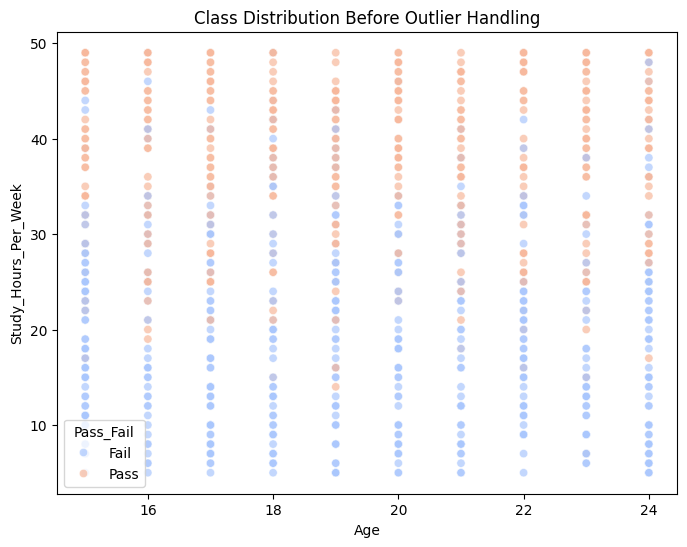

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# REMOVE TARGET ONLY IF IT IS NUMERIC
if target_col in num_cols:
    num_cols.remove(target_col)

# SAFETY CHECK
if len(num_cols) < 2:
    raise ValueError("Not enough numerical columns to plot.")

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x=num_cols[0],
    y=num_cols[1],
    hue=target_col,
    palette="coolwarm",
    alpha=0.7
)
plt.title("Class Distribution Before Outlier Handling")
plt.show()


In [8]:
def handle_outliers_iqr(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data[col] = np.where(
            data[col] < lower, lower,
            np.where(data[col] > upper, upper, data[col])
        )
    return data

df = handle_outliers_iqr(df, num_cols)


In [10]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


In [11]:
encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


In [12]:
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe())


                Age        Gender     Country  Study_Hours_Per_Week  \
count  8.000000e+02  8.000000e+02  800.000000          8.000000e+02   
mean   5.440093e-17 -2.886580e-17    0.000000         -2.442491e-17   
std    1.000626e+00  1.000626e+00    1.000626          1.000626e+00   
min   -1.493943e+00 -1.043443e+00   -1.518614         -1.754602e+00   
25%   -8.054898e-01 -1.043443e+00   -1.078277         -8.900242e-01   
50%   -1.170370e-01  9.583659e-01    0.242736         -2.544610e-02   
75%    9.156423e-01  9.583659e-01    0.683074          8.391320e-01   
max    1.604095e+00  9.583659e-01    1.563749          1.703710e+00   

       Sleep_Hours_Per_Day  Screen_Time_Hours_Per_Day  Attendance_Percentage  \
count         8.000000e+02               8.000000e+02           8.000000e+02   
mean          1.931788e-16              -2.042810e-16          -3.197442e-16   
std           1.000626e+00               1.000626e+00           1.000626e+00   
min          -1.722339e+00              

In [15]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=150),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM Linear": SVC(kernel="linear", probability=True),
    "Naive Bayes": GaussianNB(),
    "SVM Poly d=2": SVC(kernel="poly", degree=2, probability=True),
    "SVM Poly d=3": SVC(kernel="poly", degree=3, probability=True)
}


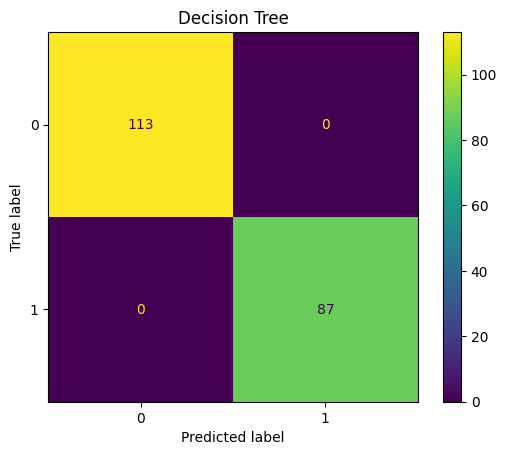

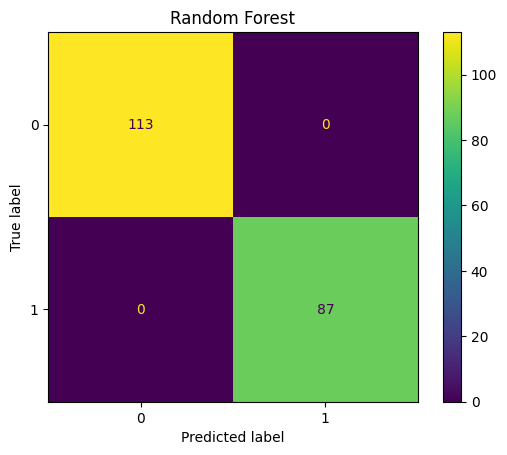

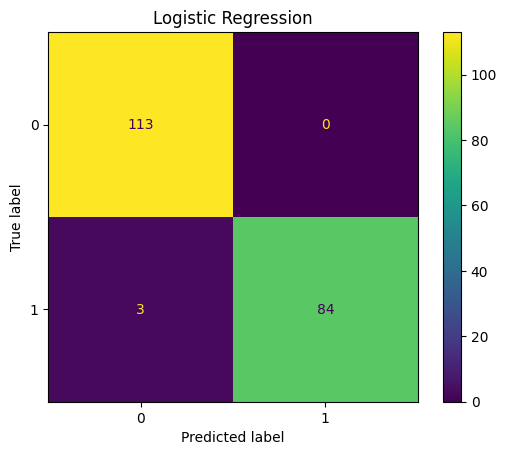

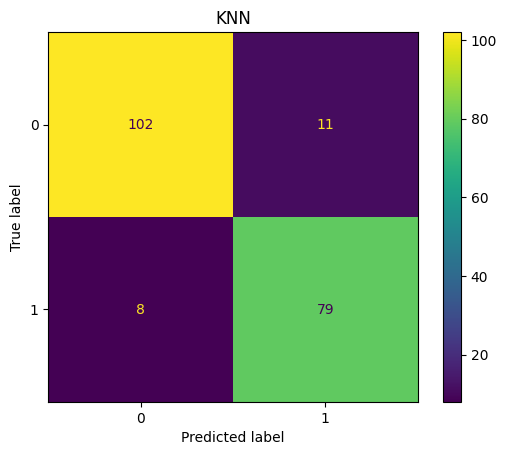

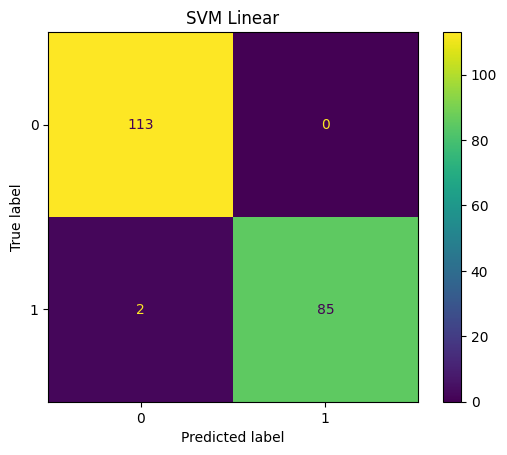

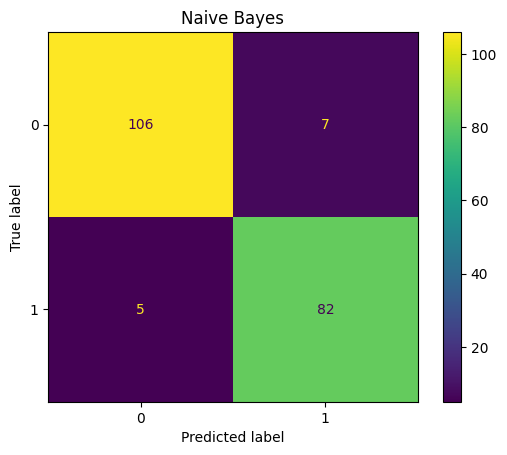

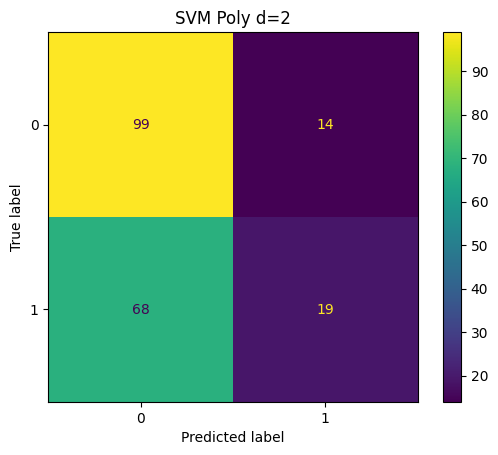

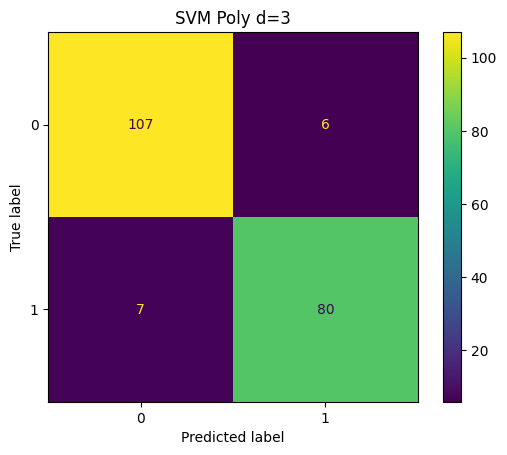

                 Model  Accuracy  Precision  Recall  F1 Score   ROC-AUC
0        Decision Tree     1.000   1.000000   1.000  1.000000  1.000000
1        Random Forest     1.000   1.000000   1.000  1.000000  1.000000
2  Logistic Regression     0.985   0.985388   0.985  0.984967  0.999695
3                  KNN     0.905   0.905742   0.905  0.905166  0.964805
4           SVM Linear     0.990   0.990174   0.990  0.989986  0.999593
5          Naive Bayes     0.940   0.940336   0.940  0.940073  0.988404
6         SVM Poly d=2     0.590   0.585395   0.590  0.537286  0.583155
7         SVM Poly d=3     0.935   0.934958   0.935  0.934955  0.985658


In [16]:
results = []
roc_data = {}

def evaluate(model, name):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted"),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(name)
    plt.show()

for name, model in models.items():
    evaluate(model, name)

results_df = pd.DataFrame(results)
print(results_df)


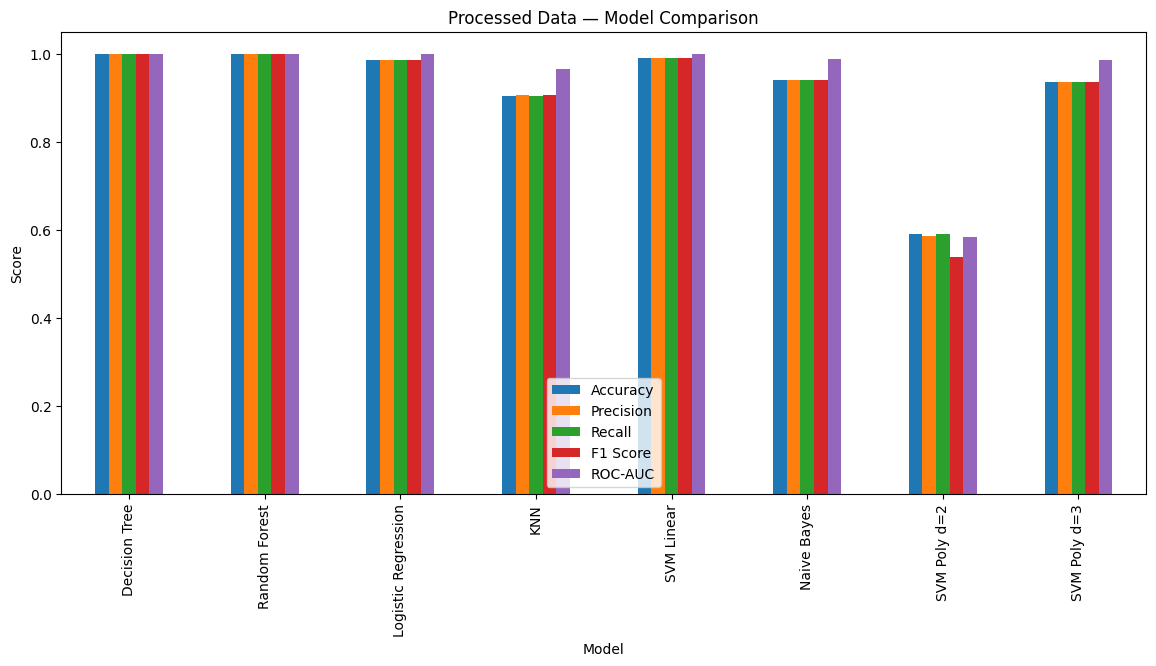

In [17]:
results_df.set_index("Model").plot(kind="bar", figsize=(14,6))
plt.title("Processed Data — Model Comparison")
plt.ylabel("Score")
plt.show()


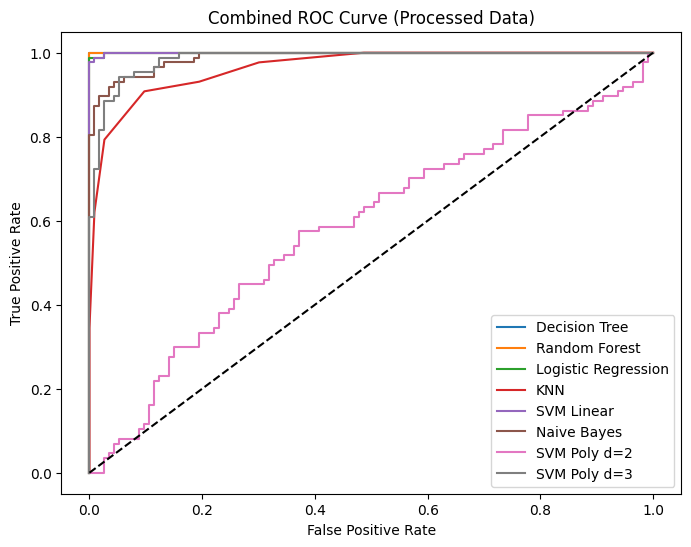

In [18]:
plt.figure(figsize=(8,6))
for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve (Processed Data)")
plt.legend()
plt.show()


In [19]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{name} → Train: {train_acc:.3f}, Test: {test_acc:.3f}")


Decision Tree → Train: 1.000, Test: 1.000
Random Forest → Train: 1.000, Test: 1.000
Logistic Regression → Train: 0.991, Test: 0.985
KNN → Train: 0.931, Test: 0.905
SVM Linear → Train: 0.991, Test: 0.990
Naive Bayes → Train: 0.946, Test: 0.940
SVM Poly d=2 → Train: 0.630, Test: 0.590
SVM Poly d=3 → Train: 0.974, Test: 0.935


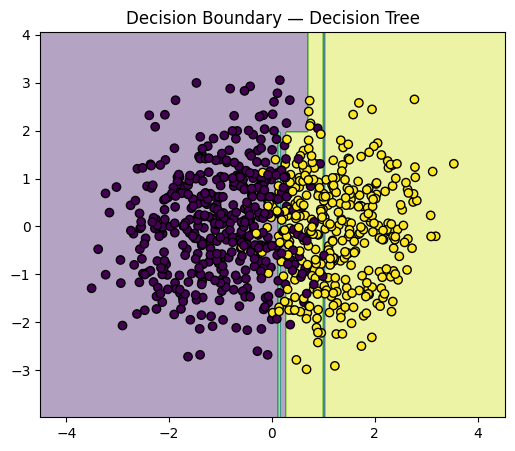

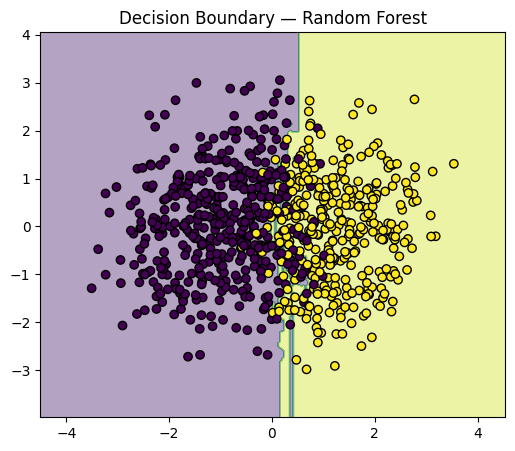

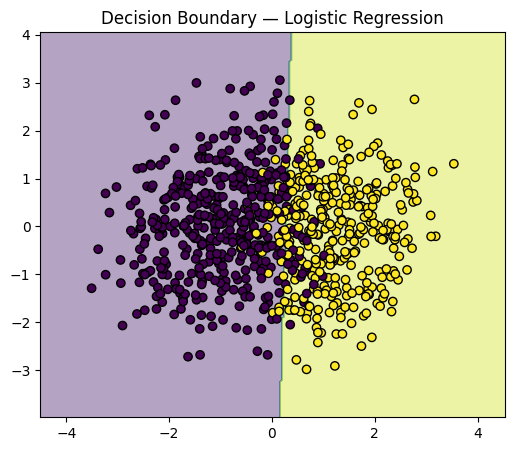

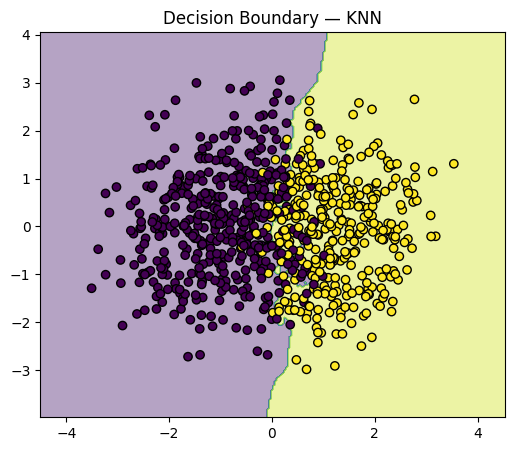

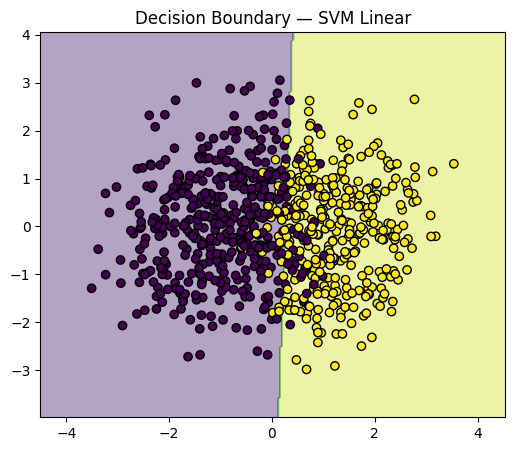

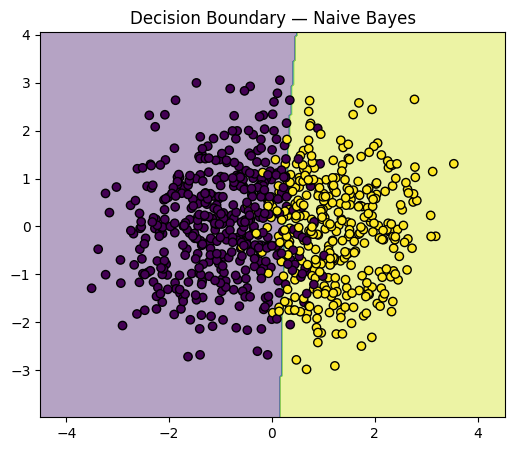

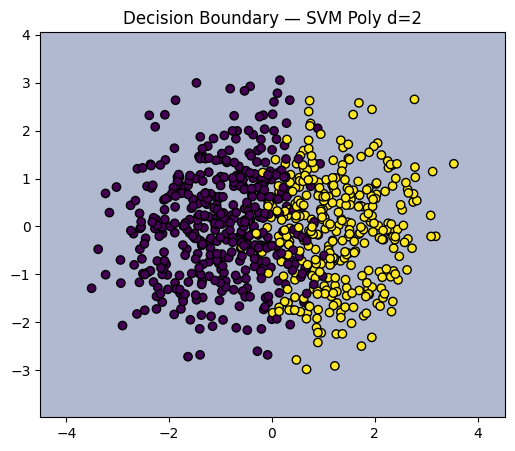

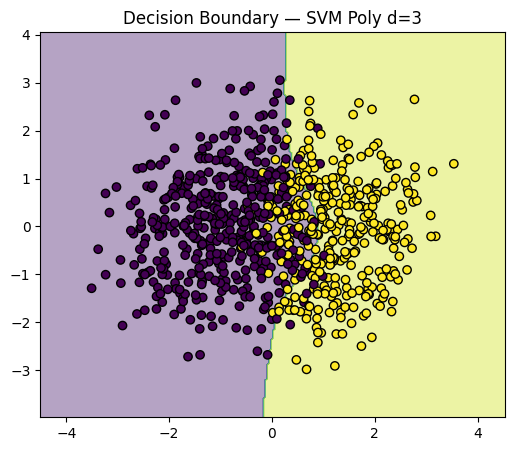

In [20]:
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_train_scaled)
y_vis = y_train.values

xx, yy = np.meshgrid(
    np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 250),
    np.linspace(X_vis[:,1].min()-1, X_vis[:,1].max()+1, 250)
)

for name, model in models.items():
    model.fit(X_vis, y_vis)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X_vis[:,0], X_vis[:,1], c=y_vis, edgecolor="k")
    plt.title(f"Decision Boundary — {name}")
    plt.show()


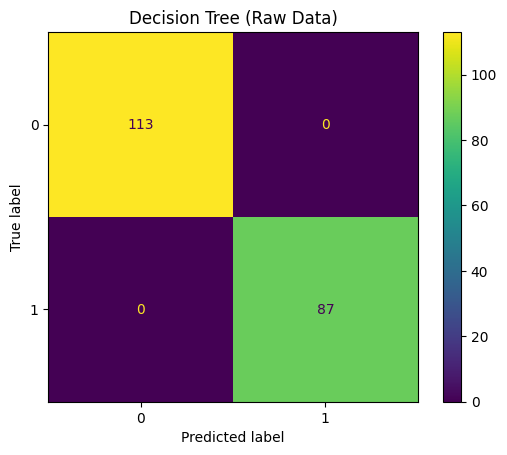

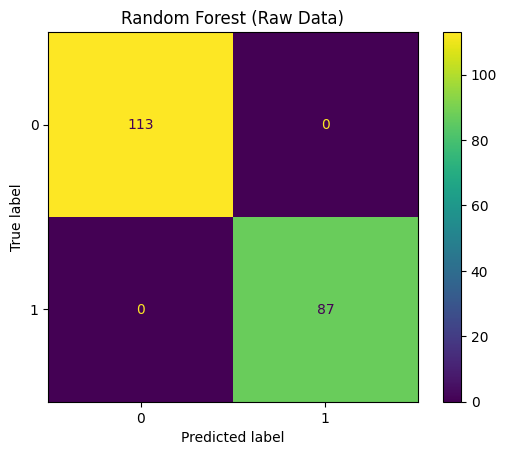

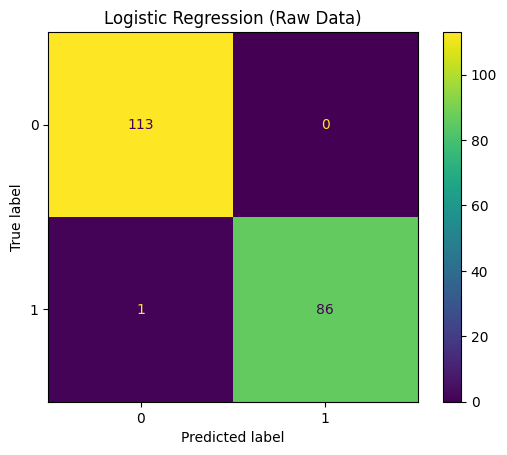

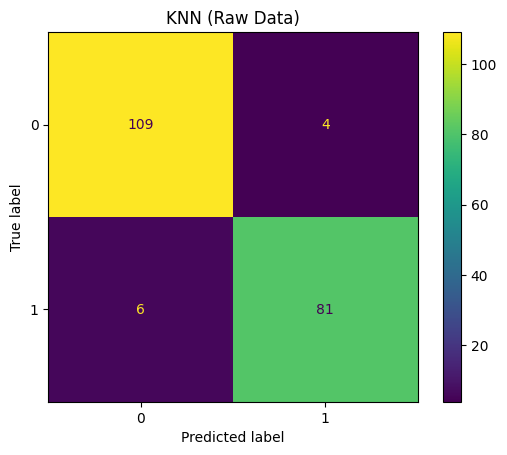

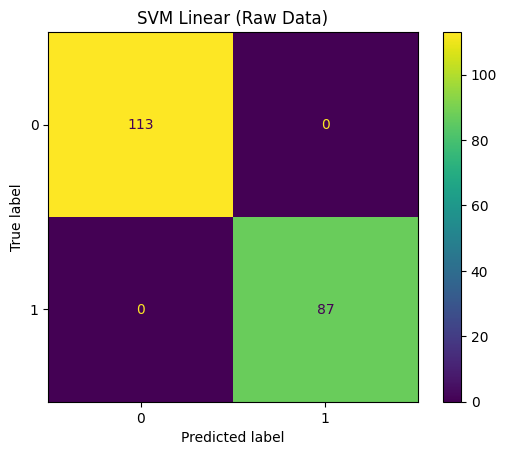

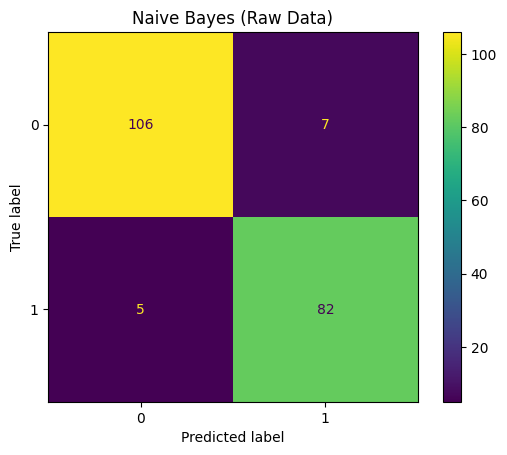

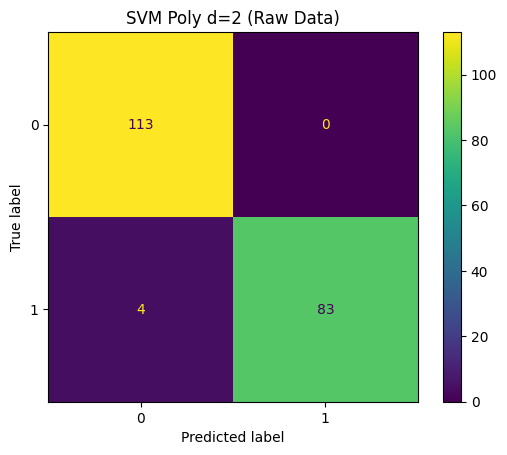

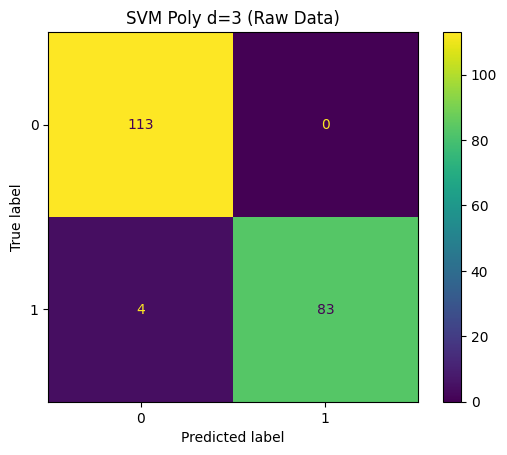

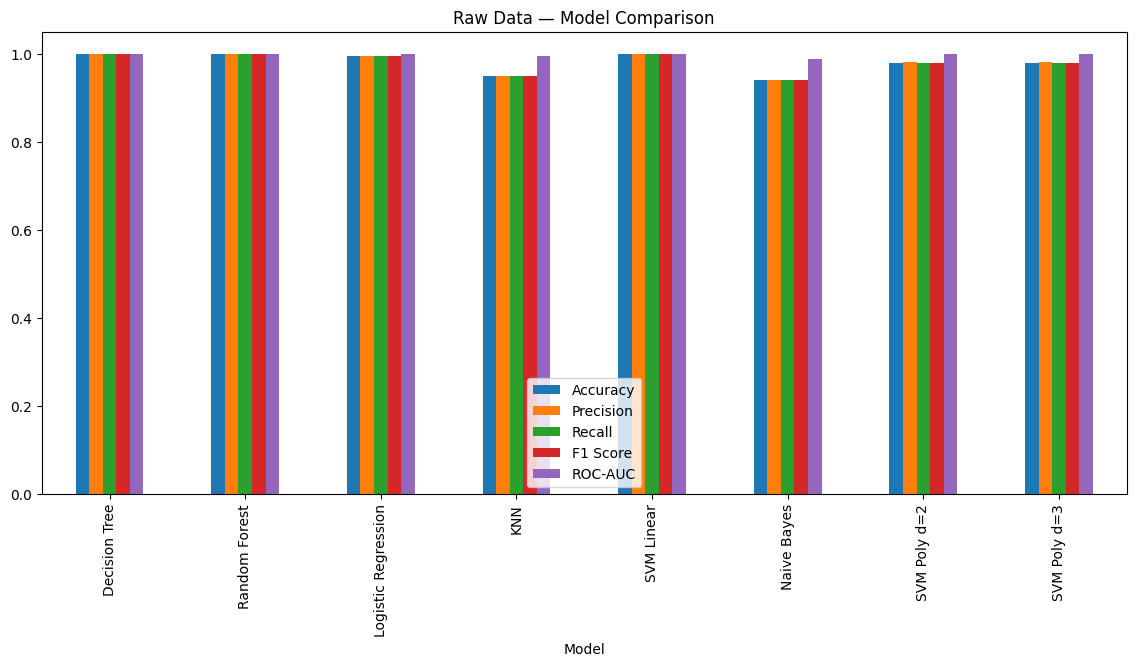

In [21]:
df_raw = pd.read_csv("D:/Machine Learning datasets/Classification/global_student_lifestyle_academic_performance.csv")

for col in df_raw.select_dtypes(include="object").columns:
    df_raw[col] = LabelEncoder().fit_transform(df_raw[col])

Xr = df_raw.drop(target_col, axis=1)
yr = df_raw[target_col]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr,
    test_size=0.2,
    random_state=42,
    stratify=yr
)

raw_results = []

for name, model in models.items():
    model.fit(Xr_train, yr_train)
    y_pred = model.predict(Xr_test)
    y_prob = model.predict_proba(Xr_test)[:, 1]

    raw_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yr_test, y_pred),
        "Precision": precision_score(yr_test, y_pred, average="weighted"),
        "Recall": recall_score(yr_test, y_pred, average="weighted"),
        "F1 Score": f1_score(yr_test, y_pred, average="weighted"),
        "ROC-AUC": roc_auc_score(yr_test, y_prob)
    })

    ConfusionMatrixDisplay.from_predictions(yr_test, y_pred)
    plt.title(f"{name} (Raw Data)")
    plt.show()

pd.DataFrame(raw_results).set_index("Model").plot(kind="bar", figsize=(14,6))
plt.title("Raw Data — Model Comparison")
plt.show()


In [22]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(df, "processed_student_performance_data.pkl")

for name, model in models.items():
    joblib.dump(model, f"{name.replace(' ', '_')}.pkl")
